In [1]:
# ============================================================
# CELDA 1 — Definición del problema
# ============================================================

from jmetal.core.problem import FloatProblem
from jmetal.core.solution import FloatSolution
from jmetal.algorithm.multiobjective.nsgaii import NSGAII
from jmetal.operator.crossover import SBXCrossover
from jmetal.operator.mutation import PolynomialMutation
from jmetal.util.termination_criterion import StoppingByEvaluations

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.datasets import load_breast_cancer
import numpy as np

class RandomForest3ObjProblem(FloatProblem):

    def __init__(self):
        super().__init__()

        # Variables: [n_estimators, max_depth, min_samples_split, criterion]
        self.lower_bound = [10,  1,  2, 0]
        self.upper_bound = [200, 20, 20, 1]

        self.data = load_breast_cancer()

    def number_of_variables(self):
        return 4

    # DIFERENCIA CLAVE: ahora son 3 objetivos
    def number_of_objectives(self):
        return 3

    def number_of_constraints(self):
        return 0

    def evaluate(self, solution):
        n_estimators      = max(10, int(round(solution.variables[0])))
        max_depth         = max(1,  int(round(solution.variables[1])))
        min_samples_split = max(2,  int(round(solution.variables[2])))
        criterion         = "gini" if round(solution.variables[3]) == 0 else "entropy"

        model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            criterion=criterion,
            random_state=42
        )

        acc_validacion = cross_val_score(
            model,
            self.data.data,
            self.data.target,
            cv=5
        ).mean()

        # Objetivo 1: Maximizar accuracy → invertir signo
        solution.objectives[0] = -acc_validacion

        # Objetivo 2 (Opción A): Minimizar n_estimators → normalizado [0,1]
        solution.objectives[1] = n_estimators / 200.0

        # Objetivo 3 (Opción B): Minimizar max_depth → normalizado [0,1]
        solution.objectives[2] = max_depth / 20.0

        return solution

    def create_solution(self):
        return FloatSolution(
            self.lower_bound,
            self.upper_bound,
            self.number_of_objectives()
        )

    def name(self):
        return "RandomForest: 3 Objetivos (Accuracy vs N_Estimators vs Max_Depth)"

In [ ]:
#ejecucion

problem = RandomForest3ObjProblem()

# NSGA-II soporta 3 objetivos, aunque para 3+ se suele preferir NSGA-III
# Un problema con mas de 3 objetivos es many-objective optimization, y requiere algoritmos específicos (NSGA-III, MOEA/D, etc.)

algorithm = NSGAII(
    problem=problem,
    population_size=40,                                                      # Más población: el espacio de búsqueda es mayor con 3 objetivos
    offspring_population_size=40,
    mutation=PolynomialMutation(probability=0.25, distribution_index=20),
    crossover=SBXCrossover(probability=0.9, distribution_index=20),
    termination_criterion=StoppingByEvaluations(max_evaluations=400)         # Más evaluaciones por la misma razón
)

algorithm.run()

pareto_front = algorithm.result()

print(f"Soluciones en el Frente de Pareto: {len(pareto_front)}\n")
print(f"{'#':<4} {'n_est':<7} {'depth':<7} {'criterion':<10} {'Acc. Val':<10} {'N_Est (norm)':<14} {'Depth (norm)':<12}")
print("-" * 68)

for i, solution in enumerate(pareto_front):
    n_est     = max(10, int(round(solution.variables[0])))
    depth     = max(1,  int(round(solution.variables[1])))
    criterion = "gini" if round(solution.variables[3]) == 0 else "entropy"
    acc_val   = round(-solution.objectives[0], 4)
    n_norm    = round(solution.objectives[1], 4)
    d_norm    = round(solution.objectives[2], 4)

    print(f"{i:<4} {n_est:<7} {depth:<7} {criterion:<10} {acc_val:<10} {n_norm:<14} {d_norm:<12}")

# Extremos del frente
mejor_acc   = min(pareto_front, key=lambda s: s.objectives[0])
menor_nest  = min(pareto_front, key=lambda s: s.objectives[1])
menor_depth = min(pareto_front, key=lambda s: s.objectives[2])

print("\n--- Extremos del Frente de Pareto ---")
print(f"Mayor accuracy    → acc: {round(-mejor_acc.objectives[0], 4)}  |  n_est: {max(10, int(round(mejor_acc.variables[0])))}  |  depth: {max(1, int(round(mejor_acc.variables[1])))}")
print(f"Menor n_estimators → acc: {round(-menor_nest.objectives[0], 4)}  |  n_est: {max(10, int(round(menor_nest.variables[0])))}  |  depth: {max(1, int(round(menor_nest.variables[1])))}")
print(f"Menor max_depth   → acc: {round(-menor_depth.objectives[0], 4)}  |  n_est: {max(10, int(round(menor_depth.variables[0])))}  |  depth: {max(1, int(round(menor_depth.variables[1])))}")

[2026-05-04 00:29:11,395] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-05-04 00:29:11,396] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-05-04 00:29:14,996] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-05-04 00:29:14,997] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-05-04 00:29:53,168] [jmetal.core.algorithm] [DEBUG] Finished!


Soluciones en el Frente de Pareto: 40

#    n_est   depth   criterion  Acc. Val   N_Est (norm)   Depth (norm)
--------------------------------------------------------------------
0    10      1       gini       0.921      0.05           0.05        
1    29      1       gini       0.9227     0.145          0.05        
2    10      5       gini       0.9561     0.05           0.25        
3    10      1       gini       0.921      0.05           0.05        
4    23      4       gini       0.9543     0.115          0.2         
5    10      2       gini       0.9473     0.05           0.1         
6    28      4       gini       0.9561     0.14           0.2         
7    10      4       gini       0.9526     0.05           0.2         
8    10      3       gini       0.9508     0.05           0.15        
9    10      2       gini       0.9473     0.05           0.1         
10   25      2       gini       0.9491     0.125          0.1         
11   10      3       gini       0.9508  

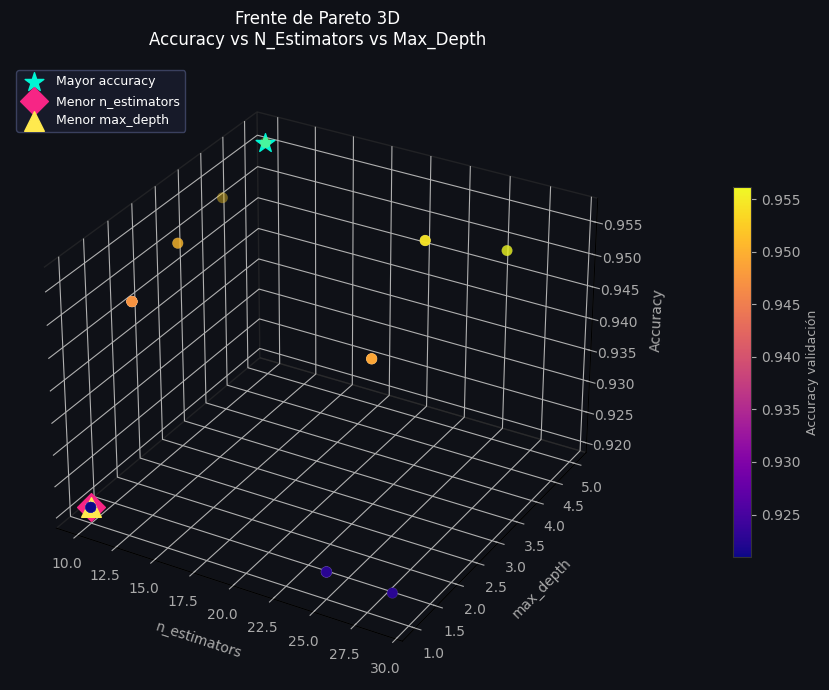

In [3]:
#visualizacion

import matplotlib.pyplot as plt
import numpy as np

accuracies   = [-s.objectives[0] for s in pareto_front]
n_estimators = [max(10, int(round(s.variables[0]))) for s in pareto_front]
max_depths   = [max(1,  int(round(s.variables[1]))) for s in pareto_front]

idx_mejor_acc   = int(np.argmax(accuracies))
idx_menor_nest  = int(np.argmin(n_estimators))
idx_menor_depth = int(np.argmin(max_depths))

fig = plt.figure(figsize=(11, 7))
fig.patch.set_facecolor("#0f1117")

ax = fig.add_subplot(111, projection="3d")
ax.set_facecolor("#0f1117")

# Puntos del frente coloreados por accuracy
scatter = ax.scatter(
    n_estimators,
    max_depths,
    accuracies,
    c=accuracies,
    cmap="plasma",
    s=60,
    edgecolors="#ffffff22",
    linewidths=0.5,
    depthshade=True
)

# Destacar extremos
ax.scatter(*[n_estimators[idx_mejor_acc]],   *[max_depths[idx_mejor_acc]],   *[accuracies[idx_mejor_acc]],
           s=200, color="#00f5d4", zorder=5, label="Mayor accuracy",     marker="*")
ax.scatter(*[n_estimators[idx_menor_nest]],  *[max_depths[idx_menor_nest]],  *[accuracies[idx_menor_nest]],
           s=200, color="#f72585", zorder=5, label="Menor n_estimators", marker="D")
ax.scatter(*[n_estimators[idx_menor_depth]], *[max_depths[idx_menor_depth]], *[accuracies[idx_menor_depth]],
           s=200, color="#ffe94e", zorder=5, label="Menor max_depth",    marker="^")

# Colorbar
cbar = fig.colorbar(scatter, ax=ax, pad=0.1, shrink=0.6)
cbar.set_label("Accuracy validación", color="#aaaaaa", fontsize=9)
cbar.ax.yaxis.set_tick_params(color="#aaaaaa")
plt.setp(cbar.ax.yaxis.get_ticklabels(), color="#aaaaaa")
cbar.outline.set_edgecolor("#333333")

# Estilos de ejes
ax.set_xlabel("n_estimators",  color="#aaaaaa", fontsize=10, labelpad=8)
ax.set_ylabel("max_depth",     color="#aaaaaa", fontsize=10, labelpad=8)
ax.set_zlabel("Accuracy",      color="#aaaaaa", fontsize=10, labelpad=8)
ax.set_title("Frente de Pareto 3D\nAccuracy vs N_Estimators vs Max_Depth",
             color="#ffffff", fontsize=12, pad=14)

ax.tick_params(colors="#aaaaaa")
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor("#333333")
ax.yaxis.pane.set_edgecolor("#333333")
ax.zaxis.pane.set_edgecolor("#333333")
ax.grid(color="#222533", linestyle="--", linewidth=0.5)

ax.legend(facecolor="#1a1d2e", edgecolor="#444c6e", labelcolor="#ffffff", fontsize=9, loc="upper left")

plt.tight_layout()
plt.show()